In [1]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel))
library(tidyr)
library(foreach)
library(doParallel)
library(tidygraph)
library(anndata)
suppressMessages(library(cowplot))
# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)



载入程序包：‘tidyr’


The following object is masked from ‘package:igraph’:

    crossing


载入需要的程序包：iterators


载入程序包：‘tidygraph’


The following object is masked from ‘package:igraph’:

    groups


The following object is masked from ‘package:stats’:

    filter



载入程序包：‘anndata’


The following object is masked from ‘package:SeuratObject’:

    Layers




In [2]:
data1 = read_h5ad('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/SN.h5ad')

seurat = CreateSeuratObject(counts = t(data1$X),meta.data = data1$obs)

seurat

Warning message:
“Data is of class dgRMatrix. Coercing to dgCMatrix.”


An object of class Seurat 
20718 features across 106790 samples within 1 assay 
Active assay: RNA (20718 features, 0 variable features)
 1 layer present: counts

In [4]:
seurat@meta.data %>% head()

,orig.ident,nCount_RNA,nFeature_RNA,Species,Animal,sample_name,Library,main structure,area,path,matrix_dir
,<fct>,<dbl>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
cDNA-250115020:CELL1_N2,SeuratProject,2232,1560,macaque,Mq246,MQ246A-150,cDNA-250115020,Midbrain,SN,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250115020/output/filter_matrix
cDNA-250115020:CELL2_N5,SeuratProject,4005,2432,macaque,Mq246,MQ246A-150,cDNA-250115020,Midbrain,SN,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250115020/output/filter_matrix
cDNA-250115020:CELL3_N4,SeuratProject,3040,1937,macaque,Mq246,MQ246A-150,cDNA-250115020,Midbrain,SN,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250115020/output/filter_matrix
cDNA-250115020:CELL5_N2,SeuratProject,4921,2899,macaque,Mq246,MQ246A-150,cDNA-250115020,Midbrain,SN,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250115020/output/filter_matrix
cDNA-250115020:CELL9_N3,SeuratProject,2950,1955,macaque,Mq246,MQ246A-150,cDNA-250115020,Midbrain,SN,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250115020/output/filter_matrix
cDNA-250115020:CELL10_N2,SeuratProject,8434,4213,macaque,Mq246,MQ246A-150,cDNA-250115020,Midbrain,SN,\\112-seqdata\\macaque\snRNA\midbrain-pons\,/mnt/112-seqdata/macaque/snRNA/resolved/20250430-zmy-anno/cDNA-250115020/output/filter_matrix


In [3]:

cellNum2 <- ncol(seurat) # nolint
cellNum2
sample_cellNum <- table(seurat$Library)

[1] 106790

In [4]:
seurat$countFeatureRatio <- seurat$nCount_RNA / seurat$nFeature_RNA
MTGenes <- c("ND6","COX1","ND5","ND4","ND2","ND4L","ATP8","CYTB","COX2","ND3","ATP6","ND1","COX3")
seurat[["percent.mt"]] <- colSums(x = GetAssayData(object = seurat, assay = "RNA", layer = "counts")
    [MTGenes, , drop = FALSE])/seurat[[paste0("nCount_","RNA")]] * 100

In [5]:
seurat = subset(seurat, nFeature_RNA > 300 & percent.mt < 5 
& countFeatureRatio > 1.2
& countFeatureRatio < 10000
& nCount_RNA < 50000)
cellNum1 = ncol(seurat)
message("Filter ratio: ", cellNum1/cellNum2)
sample_cellNum_filter <- table(seurat$Library)
sample_ratial <- sample_cellNum_filter / sample_cellNum
sample_ratial

Filter ratio: 0.94897462309205




cDNA-250114008 cDNA-250114009 cDNA-250114010 cDNA-250115019 cDNA-250115020 
     0.9449711      0.9330743      0.9258958      0.9314355      0.9581890 
cDNA-250115021 cDNA-250115022 cDNA-250115023 
     0.9619399      0.9633915      0.9579032 

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `rast

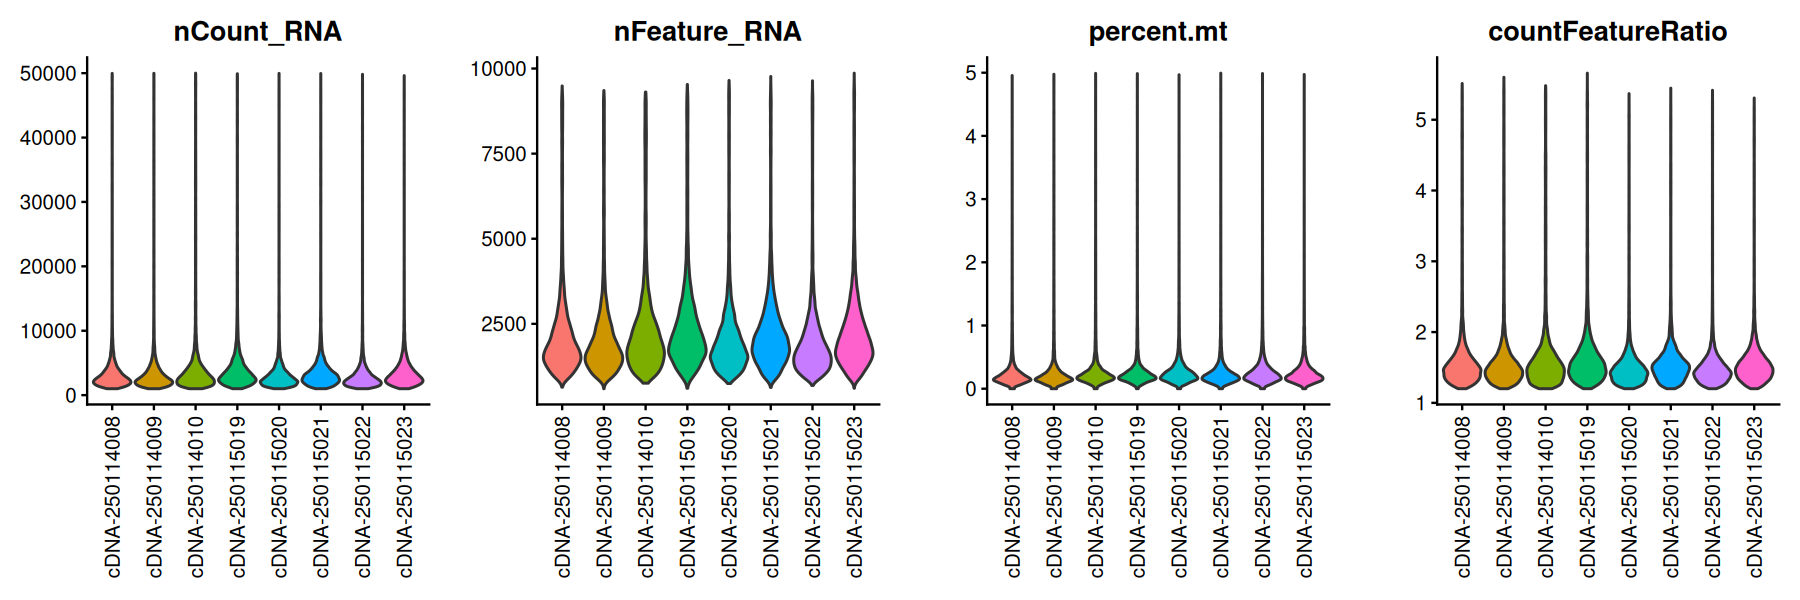

In [6]:
Idents(seurat) = "Library"
options(repr.plot.width=15, repr.plot.height=5)
print(plot_grid(
    plotlist = lapply(c("nCount_RNA", "nFeature_RNA", "percent.mt", "countFeatureRatio"), function(x) {
        p = VlnPlot(seurat, features=x, pt.size=0) + 
            theme(axis.text.x=element_text(vjust=0.5, hjust=0.5, angle=90), axis.title.x = element_blank()) +
            guides(fill=FALSE)
        return(p)
    }), 
    ncol=4, align="hv", axis="tblr"
))

In [7]:
SCTseurat = SCTransform(
    seurat, assay="RNA",
    ncells=ncol(seurat[["RNA"]]),
    variable.features.n=3000,
    vars.to.regress="percent.mt",
    return.only.var.genes = T,
    method="glmGamPoi"
)

Running SCTransform on assay: RNA

vst.flavor='v2' set. Using model with fixed slope and excluding poisson genes.

Calculating cell attributes from input UMI matrix: log_umi

Variance stabilizing transformation of count matrix of size 19942 by 101341

Model formula is y ~ log_umi

Get Negative Binomial regression parameters per gene

Using 2000 genes, 101341 cells

Found 42 outliers - those will be ignored in fitting/regularization step


Second step: Get residuals using fitted parameters for 19942 genes

Computing corrected count matrix for 19942 genes

Calculating gene attributes

Wall clock passed: Time difference of 7.239927 mins

Determine variable features

Regressing out percent.mt

Centering data matrix

Place corrected count matrix in counts slot

Set default assay to SCT



In [8]:
SCTseurat = SCTseurat %>%
    RunPCA(npcs=100, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = 0.7, random.seed = 111) %>%
    RunUMAP(dims = 1:25,umap.method = "umap-learn")

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


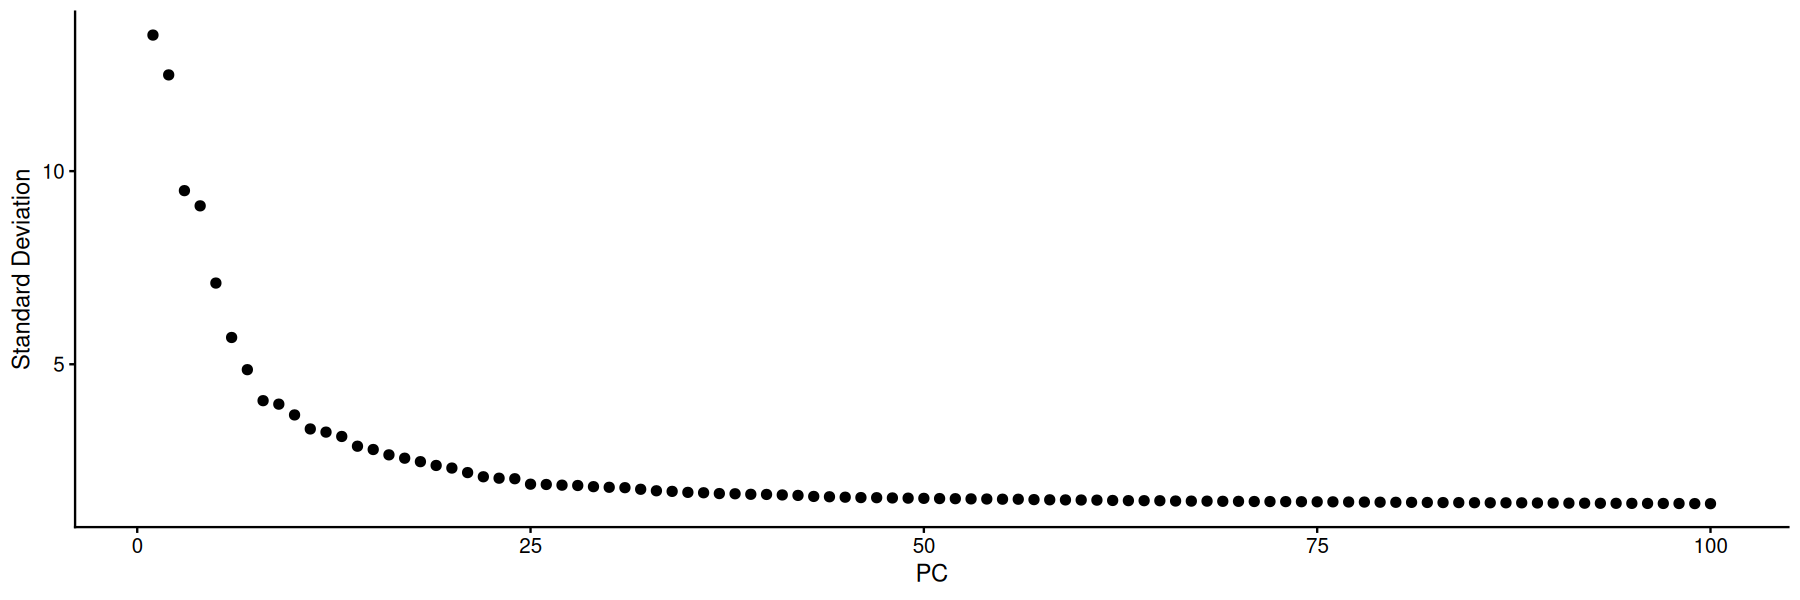

In [9]:
plot <- ElbowPlot(SCTseurat,ndims =100 , reduction = 'pca')
plot

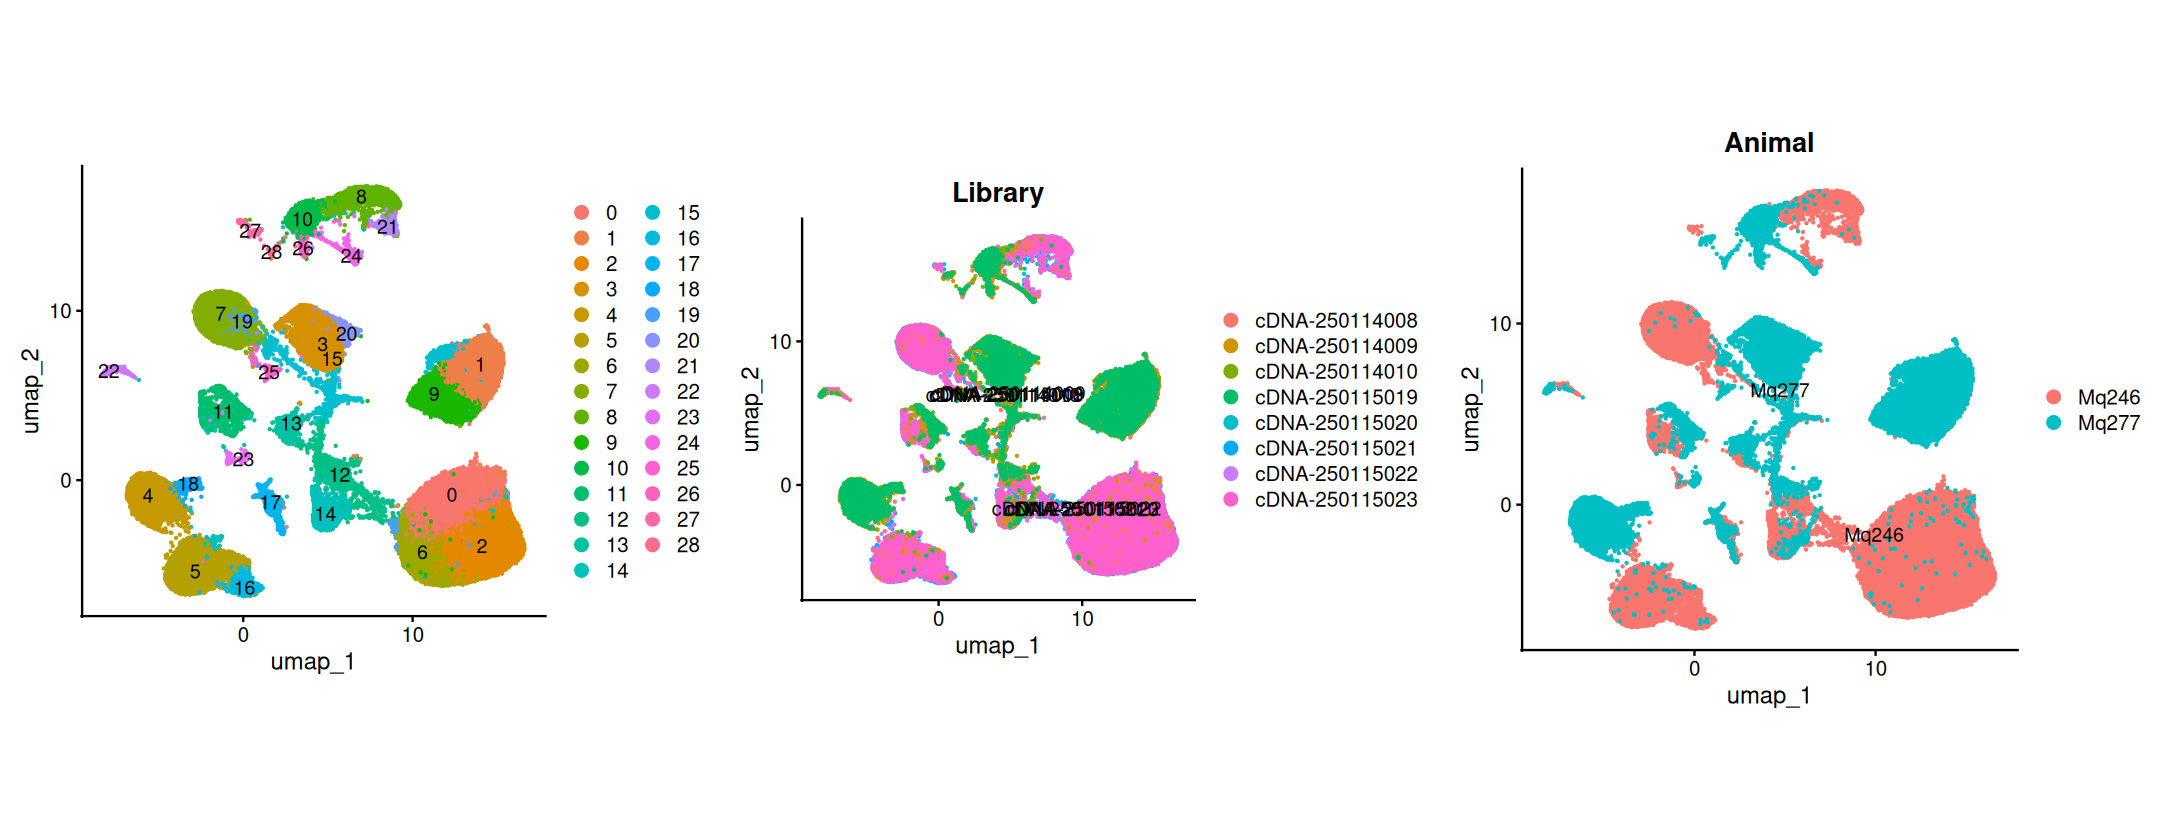

In [10]:
options(repr.plot.width=18, repr.plot.height=7)
plot_grid(
    DimPlot(SCTseurat, reduction="umap", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat, reduction="umap", group.by="Library", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),
    nrow=1
)

In [11]:
# 去批次
SCTseurat_harmony = SCTseurat %>%
    RunHarmony(group.by.vars = c("Animal"),dims.use = 1:25 ,theta = 2,reduction = "pca", max.iter.harmony = 10,sigma = 0.1,assay.use = "SCT", reduction.save = "harmony") %>%
    FindNeighbors(dims = 1:25, reduction = "harmony") %>%
    FindClusters(verbose = FALSE, resolution =0.7, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, reduction = "harmony", assay = "SCT")  

Warning message:
“Warning: The parameter max.iter.harmony is replaced with parameter max_iter. It will be ignored for this function call and please use parameter max_iter in future function calls.
This warning is displayed once per session.”
Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5067050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5067050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5067050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5067050)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 5067050)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony 5/10

Harmony converged after 5 iterations

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without dec

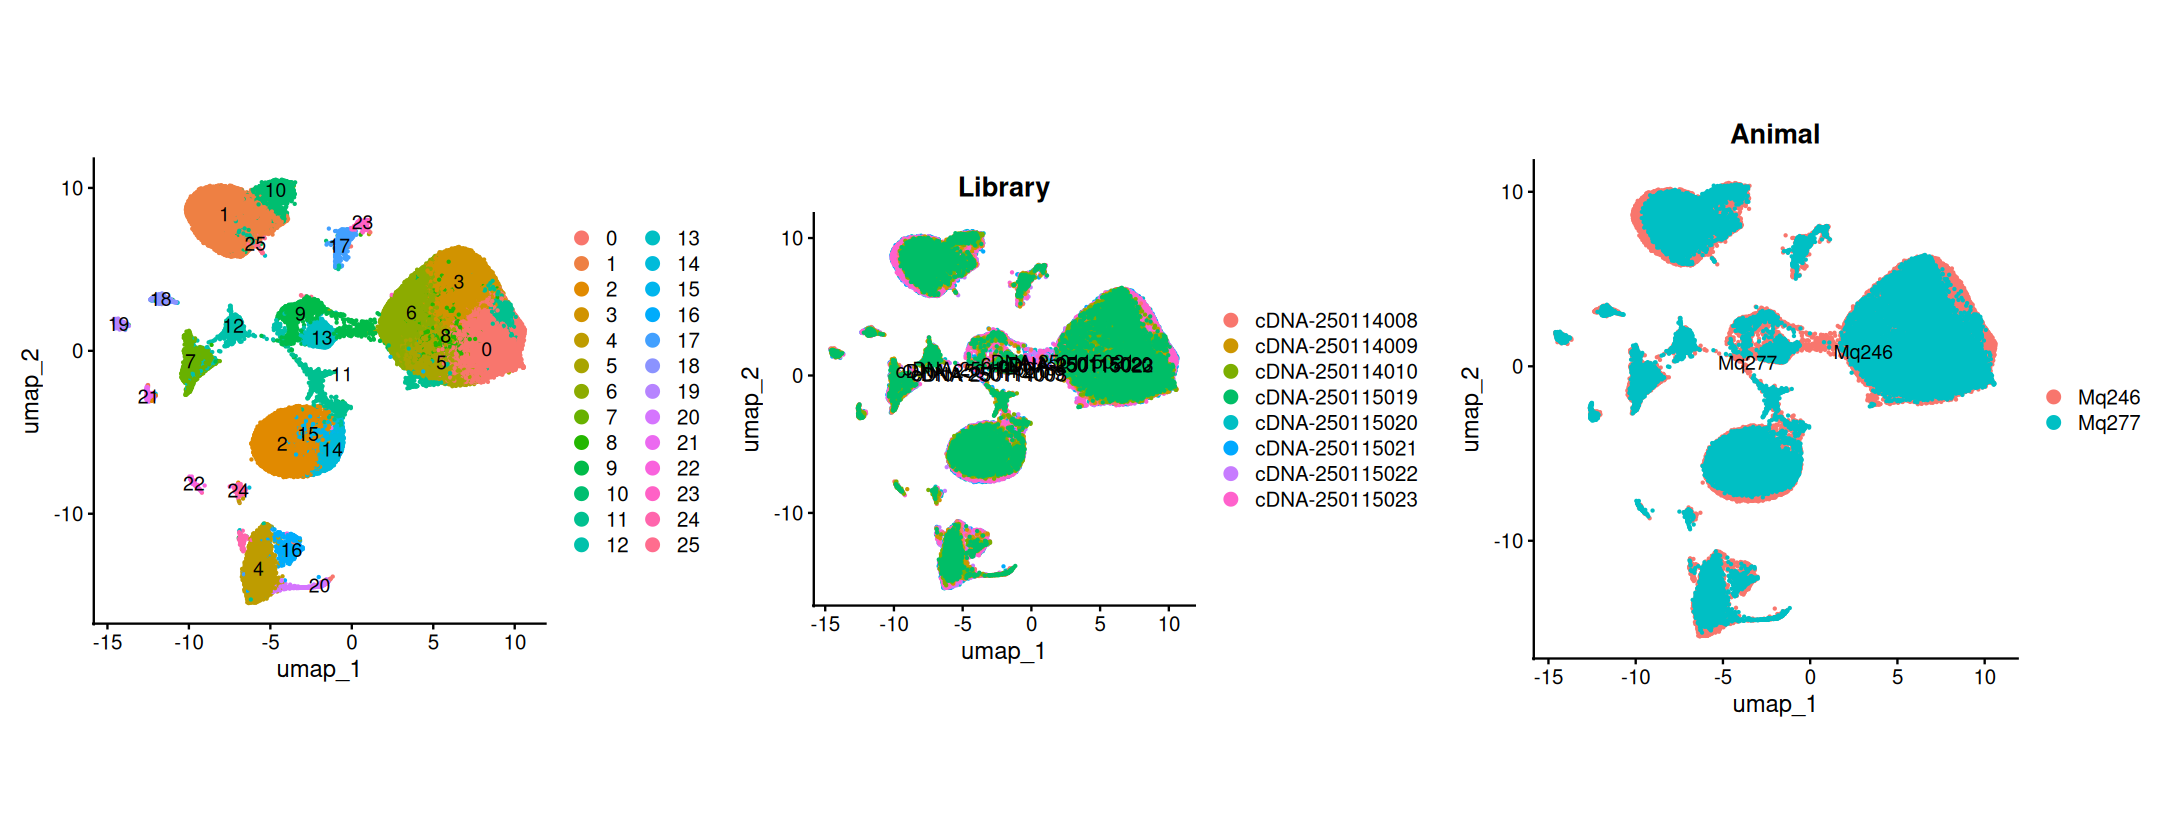

In [12]:
options(repr.plot.width=18, repr.plot.height=7)
plot_grid(
    DimPlot(SCTseurat_harmony, reduction="umap", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat_harmony, reduction="umap", group.by="Library", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat_harmony, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),
    nrow=1
)

In [13]:
df1 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/SN_1_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)
df2 = read.table('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/SN_2_Mouse_anno.csv',sep = ',',header = 1,row.names = 1)
df1 %>% head()
df2 %>% head()

,class_label,class_name,class_bootstrapping_probability,subclass_label,subclass_name,subclass_bootstrapping_probability,supertype_label,supertype_name,supertype_bootstrapping_probability,cluster_label,cluster_name,cluster_alias,cluster_bootstrapping_probability
,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>
cDNA-250114009:CELL12569_N3,CS20230722_CLAS_31,31 OPC-Oligo,0.47,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1182,1182 NFOL NN_2,1.00,CS20230722_CLUS_5278,5278 NFOL NN_2,5217,1.00
cDNA-250115019:CELL51520_N1,CS20230722_CLAS_20,20 MB GABA,0.36,CS20230722_SUBC_209,209 SCs Pax7 Nfia Gaba,0.32,CS20230722_SUPT_0859,0859 SCs Pax7 Nfia Gaba_1,0.70,CS20230722_CLUS_3746,3746 SCs Pax7 Nfia Gaba_1,3256,0.68
cDNA-250114008:CELL5396_N5,CS20230722_CLAS_31,31 OPC-Oligo,0.74,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1182,1182 NFOL NN_2,1.00,CS20230722_CLUS_5278,5278 NFOL NN_2,5217,1.00
cDNA-250114008:CELL7594_N5,CS20230722_CLAS_34,34 Immune,0.88,CS20230722_SUBC_334,334 Microglia NN,0.81,CS20230722_SUPT_1194,1194 Microglia NN_1,1.00,CS20230722_CLUS_5312,5312 Microglia NN_1,5283,1.00
cDNA-250115019:CELL2347_N2,CS20230722_CLAS_26,26 P GABA,0.33,CS20230722_SUBC_278,278 NLL Gata3 Gly-Gaba,0.77,CS20230722_SUPT_1076,1076 NLL Gata3 Gly-Gaba_3,0.98,CS20230722_CLUS_4806,4806 NLL Gata3 Gly-Gaba_3,8798,0.98
cDNA-250115020:CELL6402_N3,CS20230722_CLAS_24,24 MY Glut,0.27,CS20230722_SUBC_243,243 PGRN-PARN-MDRN Hoxb5 Glut,0.95,CS20230722_SUPT_0974,0974 PGRN-PARN-MDRN Hoxb5 Glut_2,1.00,CS20230722_CLUS_4347,4347 PGRN-PARN-MDRN Hoxb5 Glut_2,24414,1.00


,class_label,class_name,class_bootstrapping_probability,subclass_label,subclass_name,subclass_bootstrapping_probability,supertype_label,supertype_name,supertype_bootstrapping_probability,cluster_label,cluster_name,cluster_alias,cluster_bootstrapping_probability
,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>
cDNA-250114008:CELL9818_N3,CS20230722_CLAS_31,31 OPC-Oligo,0.49,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1182,1182 NFOL NN_2,0.98,CS20230722_CLUS_5278,5278 NFOL NN_2,5217,0.98
cDNA-250114008:CELL59951_N1,CS20230722_CLAS_31,31 OPC-Oligo,0.59,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1182,1182 NFOL NN_2,1.00,CS20230722_CLUS_5278,5278 NFOL NN_2,5217,1.00
cDNA-250115021:CELL2371_N2,CS20230722_CLAS_34,34 Immune,0.62,CS20230722_SUBC_334,334 Microglia NN,0.71,CS20230722_SUPT_1194,1194 Microglia NN_1,1.00,CS20230722_CLUS_5312,5312 Microglia NN_1,5283,1.00
cDNA-250115020:CELL8179_N3,CS20230722_CLAS_05,05 OB-IMN GABA,0.53,CS20230722_SUBC_045,045 OB-STR-CTX Inh IMN,0.63,CS20230722_SUPT_0171,0171 OB-STR-CTX Inh IMN_6,0.30,CS20230722_CLUS_0621,0621 OB-STR-CTX Inh IMN_6,1358,0.30
cDNA-250115020:CELL10836_N1,CS20230722_CLAS_31,31 OPC-Oligo,0.80,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1182,1182 NFOL NN_2,0.80,CS20230722_CLUS_5278,5278 NFOL NN_2,5217,0.80
cDNA-250115023:CELL14759_N2,CS20230722_CLAS_30,30 Astro-Epen,0.41,CS20230722_SUBC_318,318 Astro-NT NN,0.52,CS20230722_SUPT_1160,1160 Astro-NT NN_2,0.96,CS20230722_CLUS_5216,5216 Astro-NT NN_2,14965,0.57


In [14]:
SCTseurat_harmony_2 = SCTseurat_harmony

# 按照 index (细胞名/行名) 顺序添加
mouse_anno = c(df1$class_name, df2$class_name)
names(mouse_anno) = c(rownames(df1), rownames(df2))
# 只添加有 index 匹配的，用对象的 cell 名做索引
matched_anno = mouse_anno[colnames(SCTseurat_harmony_2)]
SCTseurat_harmony_2$Mouse_anno = matched_anno

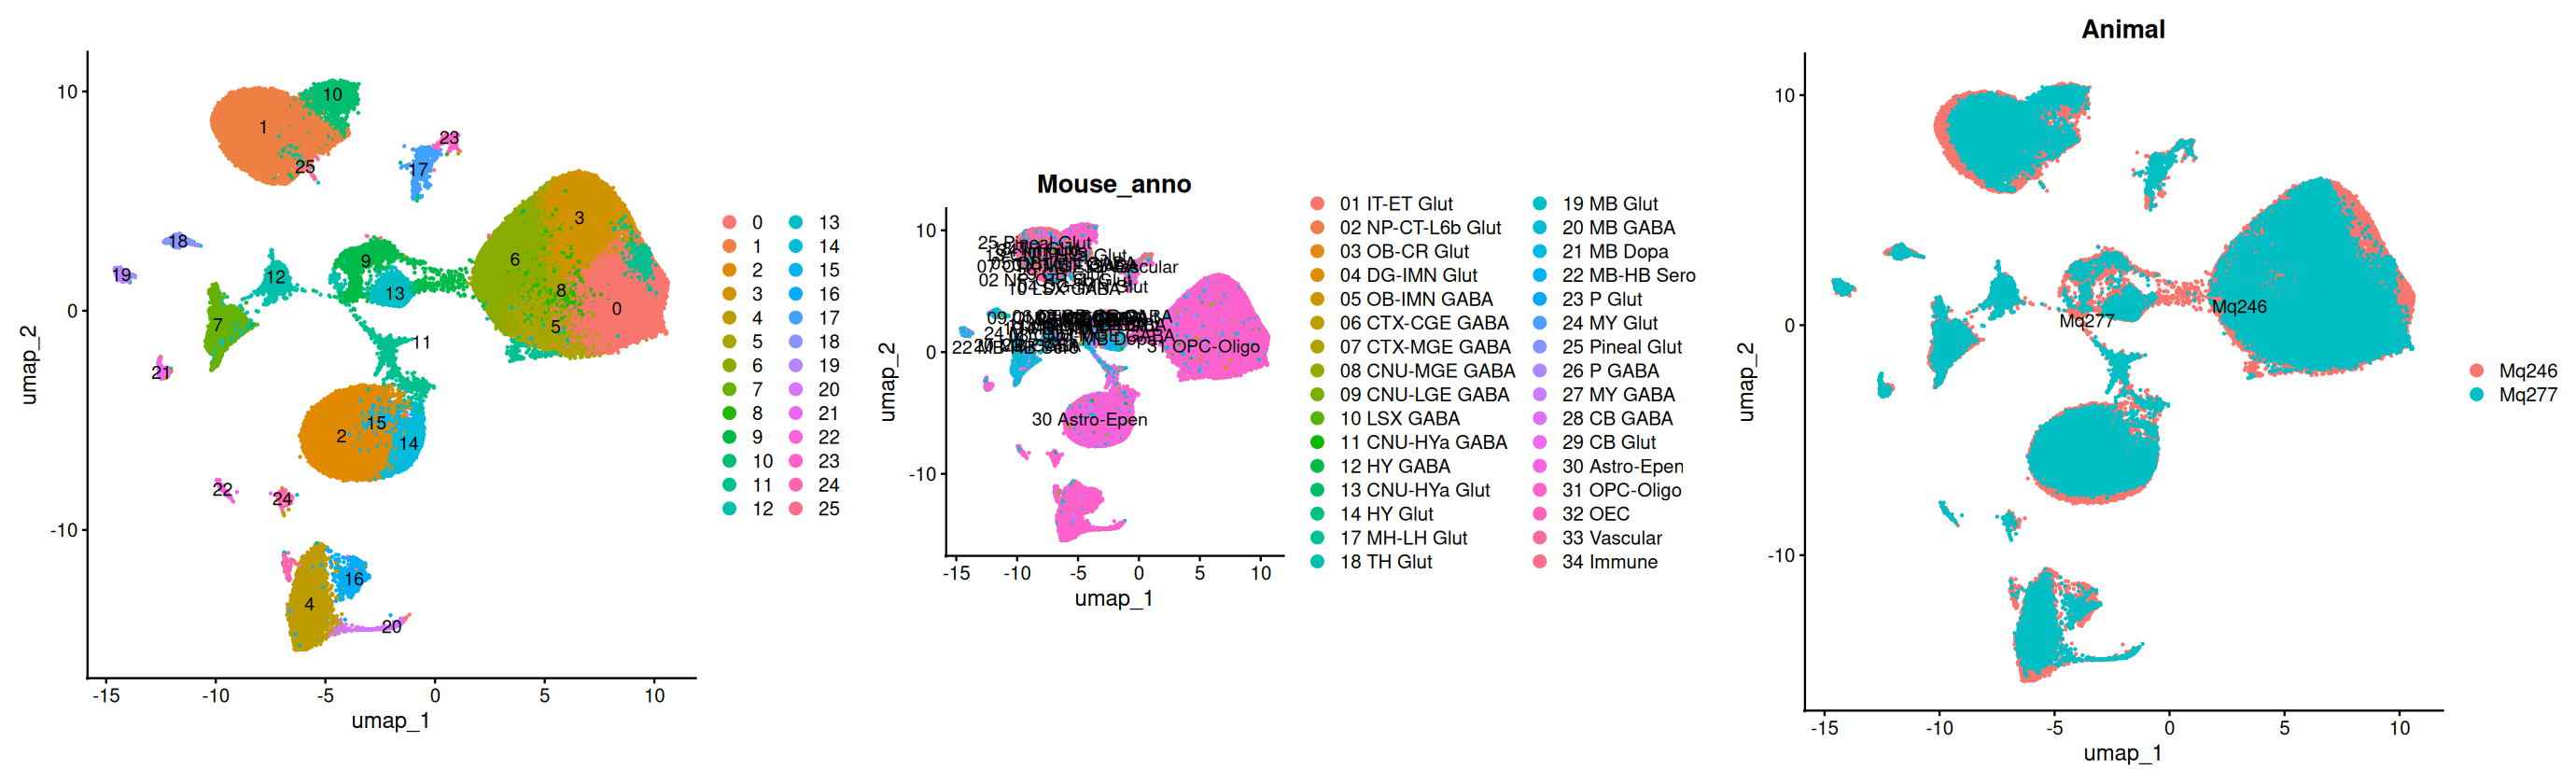

In [15]:
options(repr.plot.width=23, repr.plot.height=7)
plot_grid(
    DimPlot(SCTseurat_harmony_2, reduction="umap", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat_harmony_2, reduction="umap", group.by="Mouse_anno", label=T,raster=FALSE)+coord_fixed(),
    DimPlot(SCTseurat_harmony_2, reduction="umap", group.by="Animal", label=T,raster=FALSE)+coord_fixed(),
    nrow=1
)

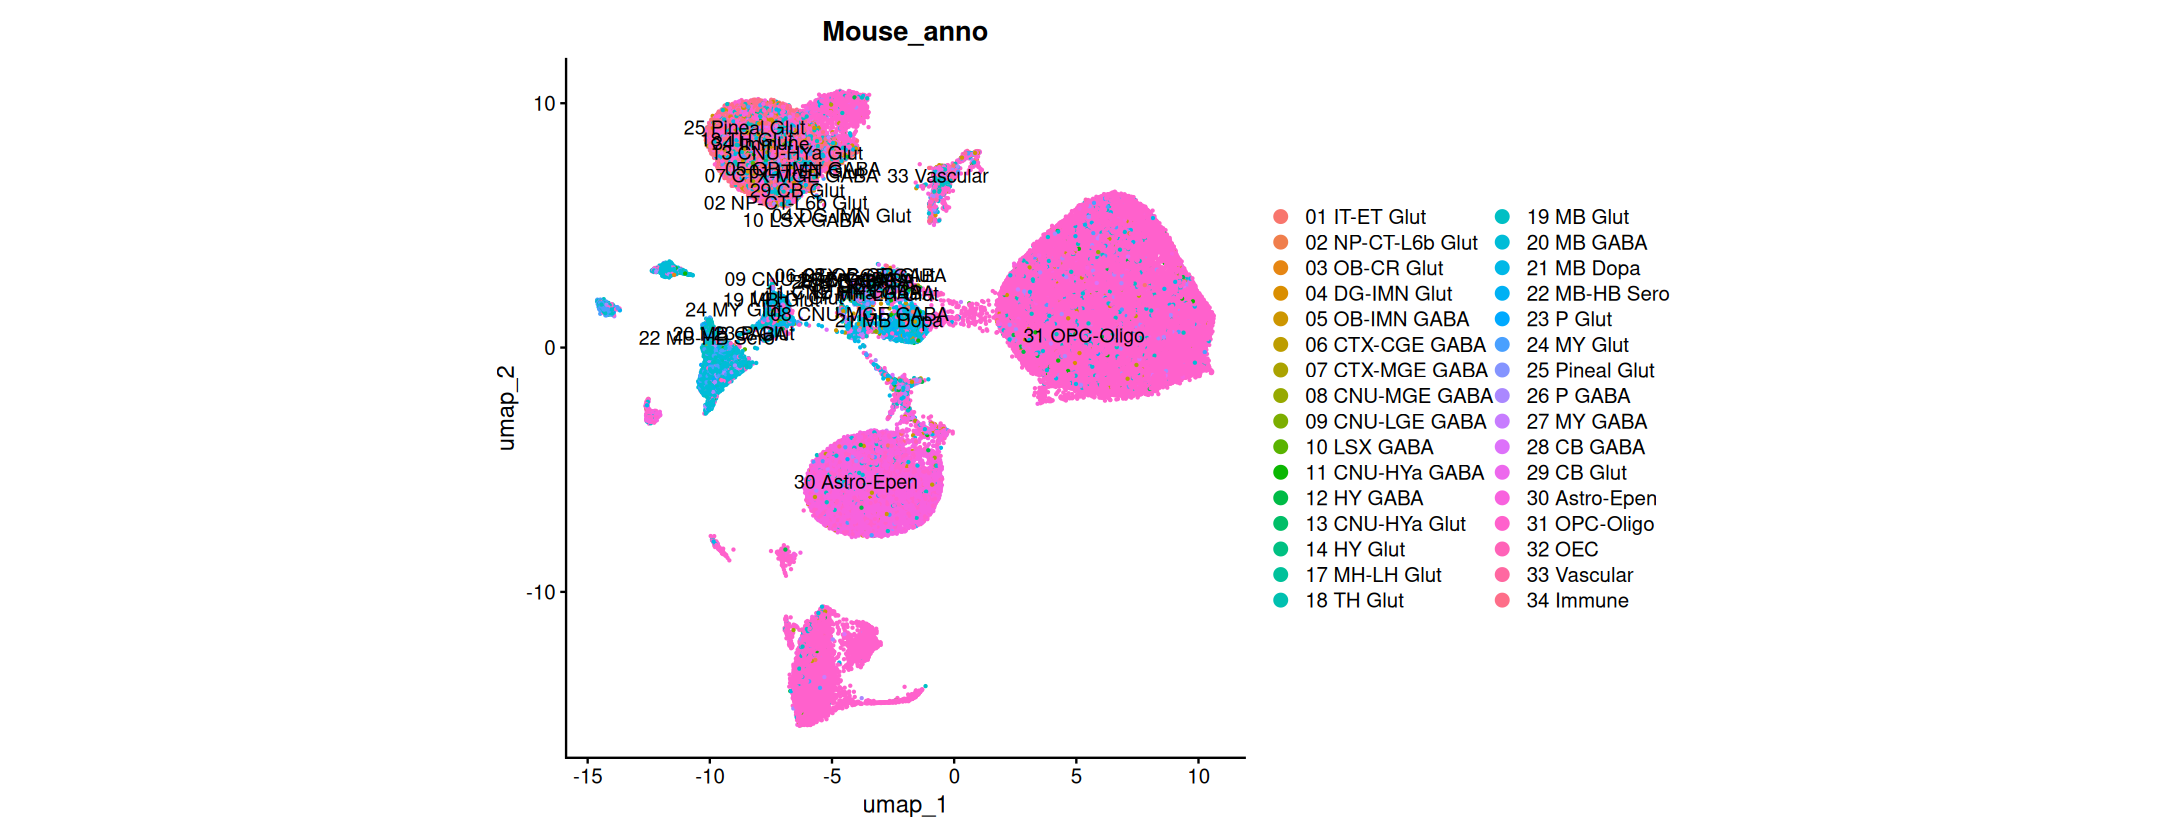

In [16]:
options(repr.plot.width=18, repr.plot.height=7)
DimPlot(SCTseurat_harmony_2, reduction="umap", group.by="Mouse_anno", label=T,raster=FALSE)+coord_fixed()

In [19]:
Neuron = c('RBFOX3', 'SNAP25', 'SYT1')
DA= c('TH', 'DDC', 'SLC6A3', 'SLC18A2', 'DRD2', 'GCH1', 'PITX3', 'NR4A2')
VTA_SNc_DA = c('CALB1', 'ALDH1A1', 'SOX6', 'SNCG', 'VIP')
GABA= c('GAD1', 'GAD2', 'SLC32A1')
Glut= c('SLC17A6', 'SLC17A7', 'SLC17A8')
Astro= c( 'GFAP', 'SLC1A2', 'SLC1A3')
Oligo= c('MOBP', 'MBP', 'PLP1', 'MOG')
OPC= c('PDGFRA', 'CSPG4', 'OLIG1', 'OLIG2')
Microglia= c('CX3CR1', 'P2RY12', 'C3', 'AIF1', 'TYROBP')
Endothelial= c('CLDN5', 'FLT1', 'PECAM1', 'VWF')
Mural= c('PDGFRB', 'RGS5')
VLMC= c('DCN', 'LUM', 'COL1A1')
Ependymal= c('FOXJ1', 'TTR', 'TMEM212')

Warning message:
“Could not find VIP in the default search locations, found in ‘RNA’ assay instead”
Warning message:
“No layers found matching search pattern provided”
Warning message in FetchData.Assay5(object = object[[assay]], vars = keyed.var, :
“data layer is not found and counts layer is used”


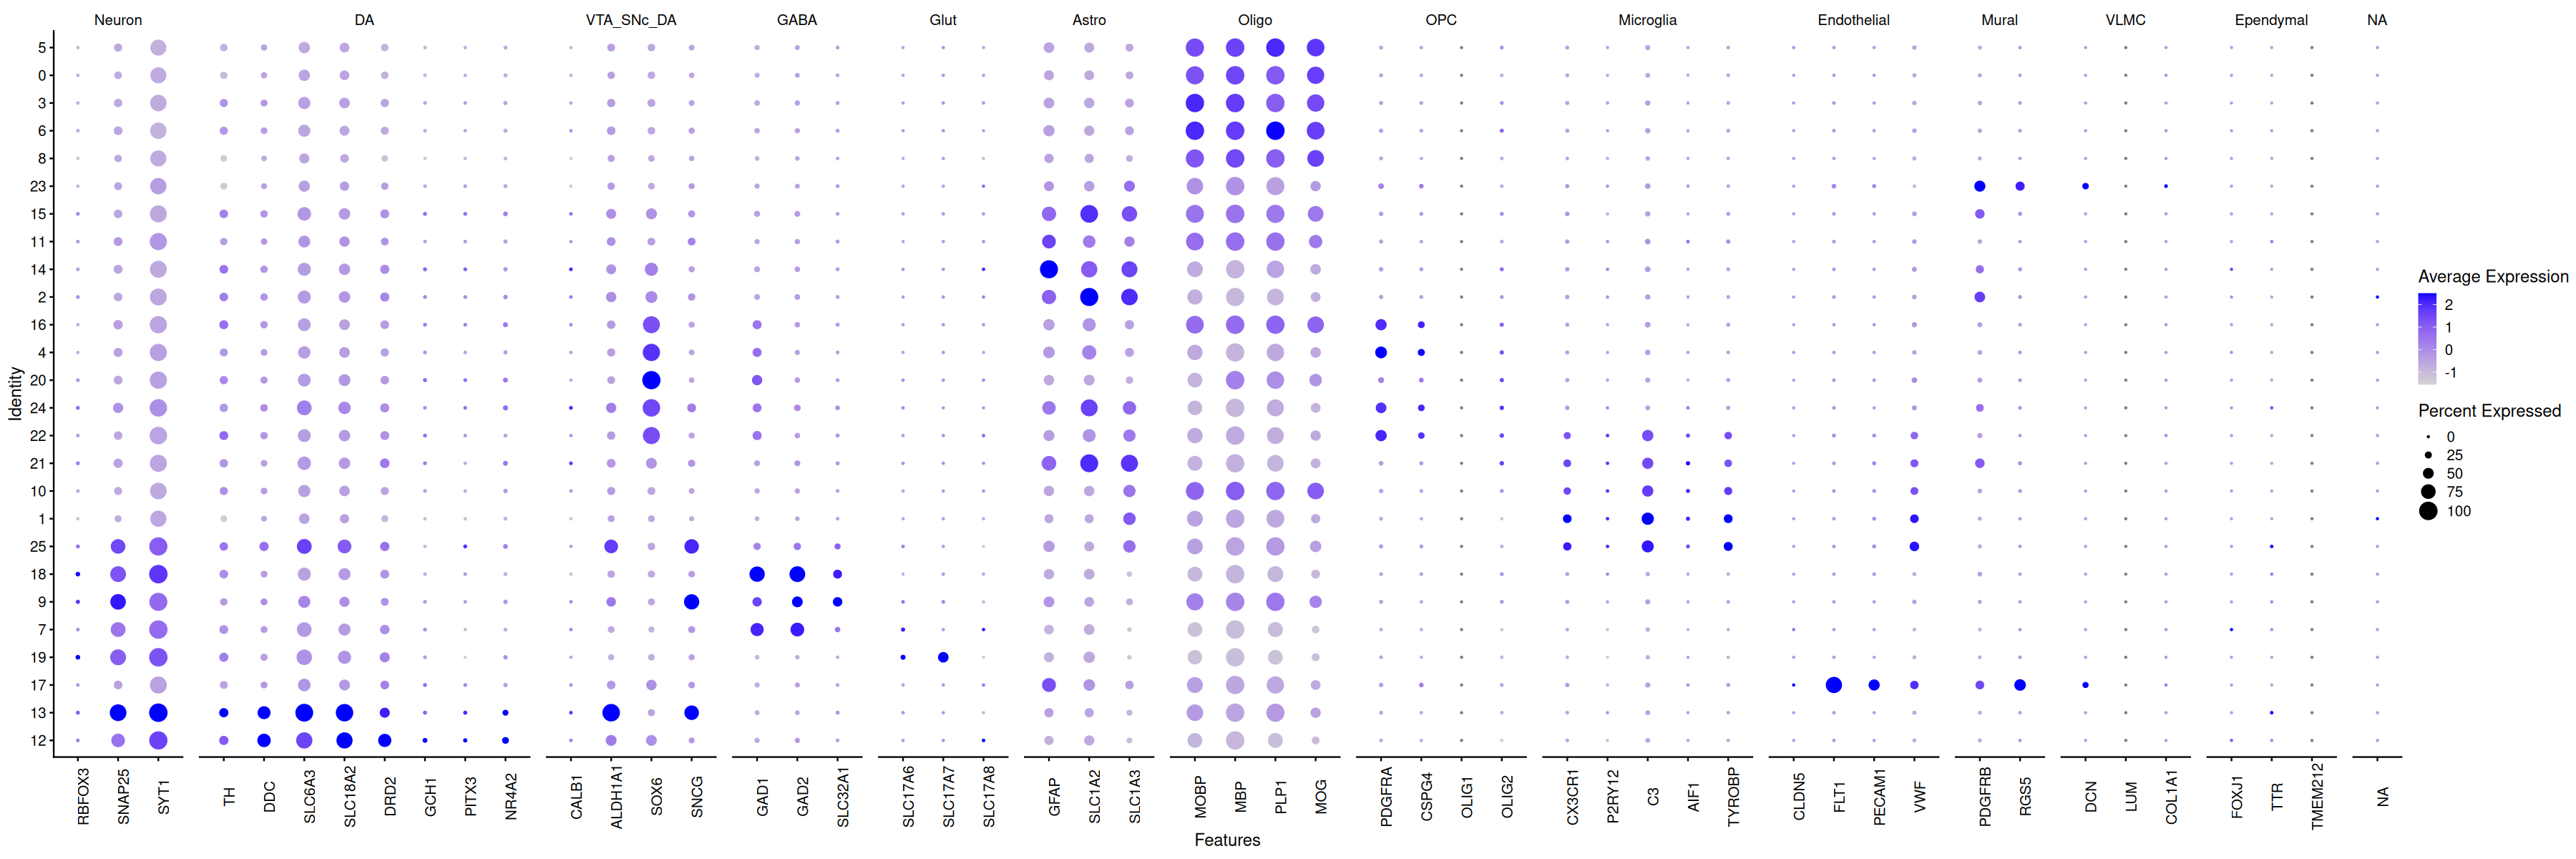

In [20]:
# selectMarkers=selectMarkers[!duplicated(selectMarkers)]
Idents(SCTseurat_harmony) = "seurat_clusters"
options(repr.plot.height=10,repr.plot.width=30)
features <- list(
"Neuron" = Neuron, 
"DA" = DA, 
"VTA_SNc_DA" = VTA_SNc_DA, 
"GABA" = GABA,  
"Glut" = Glut,
"Astro" = Astro,
"Oligo" = Oligo,
"OPC" = OPC,
"Microglia" = Microglia,
"Endothelial" = Endothelial,
"Mural" = Mural,
"VLMC" = VLMC,
"Ependymal" = Ependymal
)

features=features[!duplicated(features)]

DotPlot(SCTseurat_harmony, features = features, cluster.idents=T) + theme(axis.text.x = element_text(angle = 90))


In [17]:
Excit = c("SNAP25","SLC17A6",'NTNG1' , "RBFOX3","NEFM","NEFH","NEFL","STMN2","SERPINF1","SNCG","BHLHE22","ANXA6","TUBA4A","NRN1")

Inhib = c("GAD1", "GAD2",'DLX6','ADARB2',"FBXL7","KIT","EYA4","TRPS1")


Astrocytes = c("SLC1A2","SLC1A3","S100B", "AQP4", "APOE",'GJA1','ALDH1L1','AGT','EDNRB' ,"GFAP")
Ependymal = c("FOXJ1", "PIFO", "DYNLRB2", "RSPH1", "DNAH12", "FAM216B", "ZMYDN10", "IQCG", "ENKUR","LRRC23" )

Endotheial = c("PECAM1","VWF","CD34","VECAD" ,"CLDN5","KDR","CD105",'FLT1','RAMP2','GNG11' )
# Pericytes = c("PDGFRB", "MCAM", "RGS5", "ALPHA-SMA", "KCNJ8",'TAGLN','COX4l2','MOTCH3','ABCC9' )
OPC = c("ABRACL", "PDGFRALPHA", "OLIG2", "CSPG4", "OLIG1", "VCAN",'LHFPL3','SOX6','GPR17','BCAN',"PTPRZ1","PDGFRA","COL9A1" )
Oligo = c("PLP1",'MOG','MOBP','CLDN11','MAG','CNP','PTGDS','GPR37','FA2H','APOD' )
Microglia = c('CD68','C1QB','OLR1','HAVCR2','C1QC','CSF3R','CS3CR1','P2RY12','SALL1','TLR2',"ITGAM")

Warning message:
“The following requested variables were not found: AQP4, GJA1, DNAH12, ZMYDN10, IQCG, VECAD, CD105, PDGFRALPHA, CS3CR1”


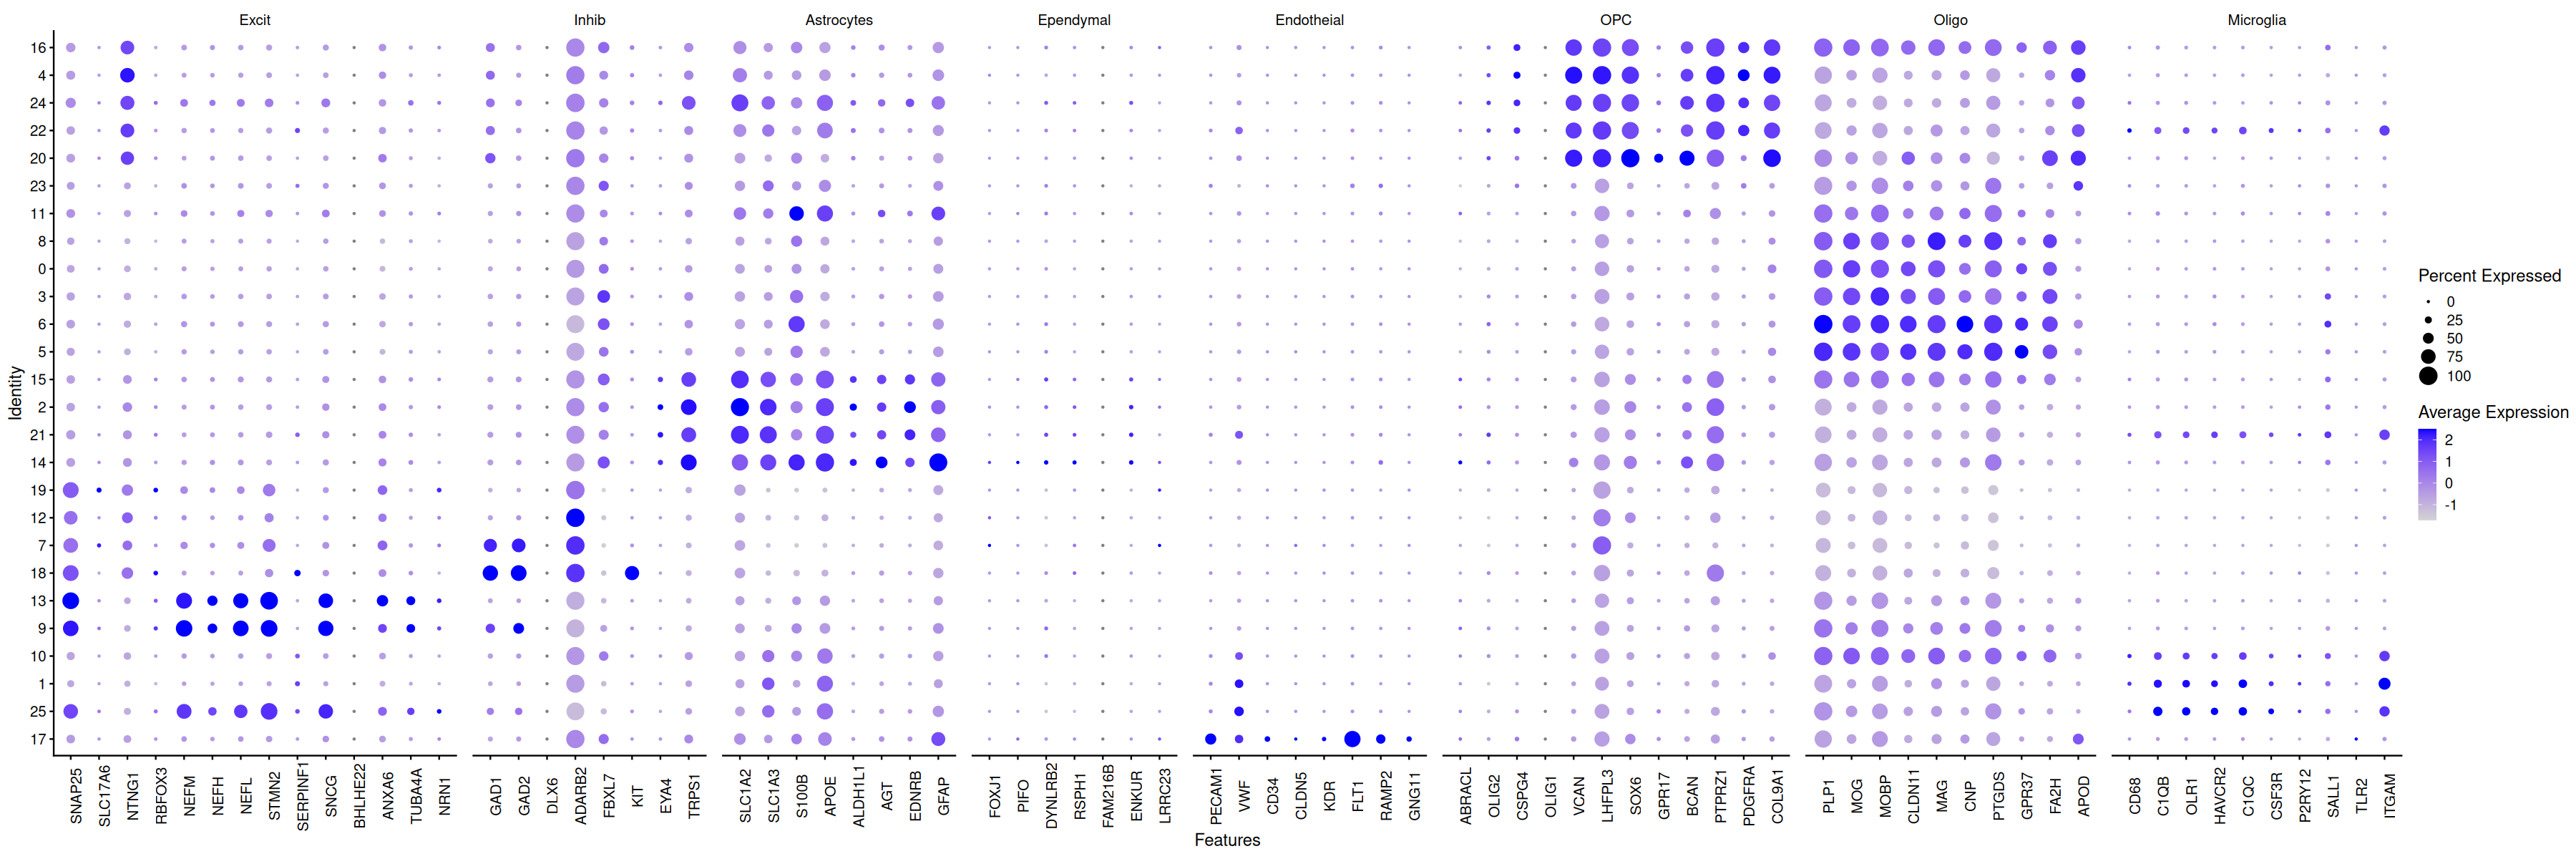

In [18]:
# selectMarkers=selectMarkers[!duplicated(selectMarkers)]
Idents(SCTseurat_harmony_2) = "seurat_clusters"
options(repr.plot.height=10,repr.plot.width=30)
features <- list(
"Excit" = Excit, 
# "layer"=layer,"deep_layer"=deep_layer, "L4_IT"=L4_IT , "L5_ET"=L5_ET , "L5_IT"=L5_IT,
# "L5_6_NP"=L5_6_NP , "L6_CT"=L6_CT , "L6_IT_CAR3"=L6_IT_CAR3 , "L6_IT"=L6_IT,"L6b"=L6b,
"Inhib" = Inhib, 
# "RELN"=RELN,"SST"=SST,
"Astrocytes" = Astrocytes, 
"Ependymal" = Ependymal,  "Endotheial" = Endotheial,
"OPC" = OPC,"Oligo" = Oligo,"Microglia" = Microglia 
)

features=features[!duplicated(features)]

DotPlot(SCTseurat_harmony_2, features = features, cluster.idents=T) + theme(axis.text.x = element_text(angle = 90))
